In [44]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
import warnings
import pyfixest as pf
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")


In [5]:
ESS11 = pd.read_csv('ESS11.csv')

In [6]:
ESS11

,name,essround,edition,proddate,idno,cntry,dweight,pspwght,pweight,anweight,...,rinwe,inwde,jinws,jinwe,inwtm,mode,domain,prob,stratum,psu
0,ESS11e04_1,11,4.1,12.01.2026,50014,AT,1.185115,0.392891,0.330915,0.130013,...,NaN,2023-11-12 15:26:55,2023-11-12 15:21:28,2023-11-12 15:26:55,30.0,1,2.0,0.000579,107,317
1,ESS11e04_1,11,4.1,12.01.2026,50030,AT,0.609898,0.325153,0.330915,0.107598,...,NaN,2023-10-18 10:44:18,2023-10-18 10:42:22,2023-10-18 10:44:18,40.0,1,1.0,0.001124,69,128
2,ESS11e04_1,11,4.1,12.01.2026,50057,AT,1.392330,4.000023,0.330915,1.323666,...,NaN,2023-09-30 14:13:33,2023-09-30 14:08:31,2023-09-30 14:13:33,42.0,1,2.0,0.000493,18,418
3,ESS11e04_1,11,4.1,12.01.2026,50106,AT,0.556061,0.176228,0.330915,0.058316,...,NaN,2023-06-30 15:11:21,2023-06-30 15:08:05,2023-06-30 15:11:21,34.0,1,1.0,0.001233,101,295
4,ESS11e04_1,11,4.1,12.01.2026,50145,AT,0.722795,1.060940,0.330915,0.351080,...,NaN,2023-07-11 11:14:03,2023-07-11 11:10:02,2023-07-11 11:14:03,57.0,1,2.0,0.000949,115,344
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50111,ESS11e04_1,11,4.1,12.01.2026,273742,UA,1.194824,1.194824,1.310703,1.566060,...,NaN,2024-05-20 21:19:06,2024-05-20 21:19:15,2024-05-20 21:22:56,37.0,1,1.0,0.000184,1492,25303
50112,ESS11e04_1,11,4.1,12.01.2026,273743,UA,0.436757,0.436757,1.310703,0.572459,...,NaN,2024-05-11 12:09:29,2024-05-11 12:09:36,2024-05-11 12:21:45,33.0,1,2.0,0.000505,1516,25311
50113,ESS11e04_1,11,4.1,12.01.2026,273747,UA,1.067750,1.067750,1.310703,1.399503,...,NaN,2024-05-23 15:50:19,2024-05-23 15:50:27,2024-05-23 15:54:37,29.0,1,1.0,0.000206,1495,25334
50114,ESS11e04_1,11,4.1,12.01.2026,273838,UA,0.597412,0.597412,1.310703,0.783030,...,NaN,2024-05-08 13:32:18,2024-05-08 13:32:23,2024-05-08 13:39:30,53.0,1,1.0,0.000369,1492,25303


In [7]:
selected_countries = [
   'AT', 'BE', 'BG', 'HR', 'CY', 'EE', 'FI', 'FR', 'DE',
   'GR', 'IT', 'LV', 'LT', 'ME', 'NL', 'NO',
   'PL', 'PT', 'RS', 'SK', 'SI', 'ES', 'SE', 'CH', 'GB'
    ]

df = ESS11[ESS11['cntry'].isin(selected_countries)].copy()
print(f"After country selection: {df.shape}")
print(f"Countries included ({len(df['cntry'].unique())}): {sorted(df['cntry'].unique())}")


After country selection: (41572, 691)
Countries included (25): ['AT', 'BE', 'BG', 'CH', 'CY', 'DE', 'EE', 'ES', 'FI', 'FR', 'GB', 'GR', 'HR', 'IT', 'LT', 'LV', 'ME', 'NL', 'NO', 'PL', 'PT', 'RS', 'SE', 'SI', 'SK']


In [11]:
vars_demographics = ['cntry', 'gndr', 'agea']
vars_education = ['eisced']
vars_income = ['hinctnta']
vars_employment = ['mnactic']
vars_trust = ['trstprl', 'trstlgl', 'trstplc', 'trstplt', 'trstprt', 'trstep']
vars_democracy = ['stfdem']
vars_immigration = ['imsmetn', 'imdfetn', 'impcntr', 'imbgeco', 'imueclt', 'imwbcnt']
vars_hostile_sexism = ['wsekpwr', 'weasoff', 'wexashr']
vars_econ_gender = ['eqpaybg', 'eqmgmbg', 'fineqpy', 'eqparlv']
vars_religiosity = ['rlgatnd']
vars_urban = ['domicil']

party_vote_vars = [col for col in df.columns if col.startswith('prtv')]
print(f"Party vote variables found: {party_vote_vars}")

all_vars = (vars_demographics + vars_education + vars_income + vars_employment +
            vars_trust + vars_democracy + vars_immigration + vars_hostile_sexism +
            vars_econ_gender + vars_religiosity + vars_urban + party_vote_vars)

existing_vars = [v for v in all_vars if v in df.columns]
missing_vars = [v for v in all_vars if v not in df.columns]
if missing_vars:
    print(f"WARNING: Variables not found in data: {missing_vars}")

df = df[existing_vars].copy()
print(f"Variables selected: {len(existing_vars)}")

Party vote variables found: ['prtvtdat', 'prtvtebe', 'prtvtfbg', 'prtvtchr', 'prtvtccy', 'prtvtiee', 'prtvtffi', 'prtvtffr', 'prtvgde1', 'prtvgde2', 'prtvtegr', 'prtvthhu', 'prtvteis', 'prtvteie', 'prtvteil', 'prtvteit', 'prtvtblv', 'prtvclt1', 'prtvclt2', 'prtvclt3', 'prtvtbme', 'prtvtinl', 'prtvtcno', 'prtvtfpl', 'prtvtept', 'prtvtbrs', 'prtvtesk', 'prtvtgsi', 'prtvtges', 'prtvtese', 'prtvthch', 'prtvtdua', 'prtvtdgb']
Variables selected: 61


In [14]:

df['agea'] = pd.to_numeric(df['agea'], errors='coerce')
df['gndr'] = pd.to_numeric(df['gndr'], errors='coerce')

df_ym = df[(df['gndr'] == 1) & (df['agea'] >= 18) & (df['agea'] <= 34)].copy()
print(f"Young men (18-34) sample size: {df_ym.shape[0]}")
print(f"Countries represented: {df_ym['cntry'].nunique()}")
print(f"Age range: {df_ym['agea'].min()} - {df_ym['agea'].max()}")


Young men (18-34) sample size: 3904
Countries represented: 25
Age range: 18 - 34


In [16]:
df_ym['cntry'].unique

<bound method Series.unique of 18       AT
22       AT
47       AT
53       AT
76       AT
         ..
47394    SK
47398    SK
47431    SK
47450    SK
47454    SK
Name: cntry, Length: 3904, dtype: object>

In [18]:
df_ym.to_csv("young_males_voting.csv", sep=',', encoding='utf-8', index=False)


In [20]:
far_right_parties = {
    'AT': ('prtvtdat',  [3]),                # FPÖ
    'BE': ('prtvtebe',  [6]),                # Vlaams Belang
    'BG': ('prtvtfbg',  [6]),                # Vazrazhdane (Revival)
    'HR': ('prtvtchr',  [3]),                # Domovinski pokret
    'CY': ('prtvtccy',  [9]),                # ELAM
    'EE': ('prtvtiee',  [6]),                # EKRE
    'FI': ('prtvtffi',  [8]),                # Finns Party
    'FR': ('prtvtffr',  [8, 9]),             # RN, Reconquête 
    'DE': ('prtvgde2',  [6]),                # AfD (Zweitstimme)
    'GR': ('prtvtegr',  [5]),                # Elliniki Lysi
    'IT': ('prtvteit',  [1, 4]),             # FdI + Lega
    'LV': ('prtvtblv',  [11]),               # National Alliance
    'LT': ('prtvclt1',  [7]),                # National Alliance (Nacionālā apvienība 'Visu Latvijai!')
    'ME': ('prtvtbme',  [8, 14]),            # Movement for Changes (Pokret za promjene, PzP),  Za budućnost Crne Gore (Nova srpska demokratija, Demokratska narodna partija Crne Gore)
    'NL': ('prtvtinl',  [3, 13, 16]),        # PVV, FvD, JA21
    'NO': ('prtvtcno',  [8]),                # FrP 
    'PL': ('prtvtfpl',  [5, 2]),             # Konfederacja, Prawo i Sprawiedliwość 
    'PT': ('prtvtept',  [5]),                # Chega 
    'RS': ('prtvtbrs',  [4, 33]),            # Srpska radikalna stranka
    'SK': ('prtvtesk',  [4, 3]),             # ĽS Naše Slovensko (ĽSNS), SME Rodina
    'SI': ('prtvtgsi',  [8, 6, 9]),          # SDS, NSI - Nova Slovenija – Kršcanski demokrati, Slovenska Nacionalna Stranka
    'ES': ('prtvtges',  [3]),                # Vox
    'SE': ('prtvtese',  [8]),                # Sweden Democrats
    'CH': ('prtvthch',  [1, 9, 10, 15]),     # SVP, Federal Democratic Union (EDU), Ticino League (Lega dei Ticinesi / LdT), Movement of the Citizens of French-speaking Switzerland
    'GB': ('prtvtdgb',  [7, 8]),             # Reform UK (Brexit Party), UK Independence Party
}


#   1 = voted for a far-right party
#   0 = voted for a non-far-right party
#   NaN = did not vote, refused, don't know, or country has no far-right coding

df_ym['far_right'] = np.nan

for cntry, (var_name, fr_codes) in far_right_parties.items():

    if var_name not in df_ym.columns:
        print(f"  {cntry}: variable '{var_name}' not found - skipping")
        continue

    cntry_mask = df_ym['cntry'] == cntry
    raw_values = pd.to_numeric(df_ym.loc[cntry_mask, var_name], errors='coerce')

    valid_vote = raw_values.notna() & (raw_values < 55)


    valid_idx = cntry_mask & valid_vote.reindex(df_ym.index, fill_value=False)
    df_ym.loc[valid_idx, 'far_right'] = 0

    # Set far-right voters to 1
    if fr_codes:
        fr_idx = cntry_mask & raw_values.reindex(df_ym.index, fill_value=np.nan).isin(fr_codes)
        df_ym.loc[fr_idx, 'far_right'] = 1

  
    n_valid = valid_idx.sum()
    n_fr = df_ym.loc[cntry_mask, 'far_right'].eq(1).sum()
    fr_pct = n_fr / n_valid * 100 if n_valid > 0 else 0
    status = f"{n_fr}/{n_valid} far-right ({fr_pct:.1f}%)" if fr_codes else f"{n_valid} voters, no FR parties coded"
    print(f"  {cntry}: {status}")

print(f"\nOverall far-right vote distribution:")
print(df_ym['far_right'].value_counts(dropna=False))
print(f"Far-right share (among valid voters): {df_ym['far_right'].dropna().mean():.3f}")

  AT: 19/70 far-right (27.1%)
  BE: 14/104 far-right (13.5%)
  BG: 5/81 far-right (6.2%)
  HR: 4/43 far-right (9.3%)
  CY: 3/12 far-right (25.0%)
  EE: 13/56 far-right (23.2%)
  FI: 27/101 far-right (26.7%)
  FR: 12/65 far-right (18.5%)
  DE: 7/153 far-right (4.6%)
  GR: 6/152 far-right (3.9%)
  IT: 35/108 far-right (32.4%)
  LV: 2/25 far-right (8.0%)
  LT: 0/33 far-right (0.0%)
  ME: 7/44 far-right (15.9%)
  NL: 16/98 far-right (16.3%)
  NO: 9/97 far-right (9.3%)
  PL: 38/99 far-right (38.4%)
  PT: 9/47 far-right (19.1%)
  RS: 1/53 far-right (1.9%)
  SK: 12/59 far-right (20.3%)
  SI: 25/77 far-right (32.5%)
  ES: 13/97 far-right (13.4%)
  SE: 15/92 far-right (16.3%)
  CH: 6/51 far-right (11.8%)
  GB: 0/74 far-right (0.0%)

Overall far-right vote distribution:
far_right
NaN    2013
0.0    1593
1.0     298
Name: count, dtype: int64
Far-right share (among valid voters): 0.158


In [22]:
hs_items = ['wsekpwr', 'weasoff', 'wexashr']

for var in hs_items:
    df_ym[var] = pd.to_numeric(df_ym[var], errors='coerce')
    df_ym.loc[df_ym[var] > 5, var] = np.nan

for var in hs_items:
    df_ym[f'{var}_z'] = (df_ym[var] - df_ym[var].mean()) / df_ym[var].std()

df_ym['hostile_sexism_raw'] = df_ym[[f'{v}_z' for v in hs_items]].mean(axis=1)
df_ym['hostile_sexism'] = (
    (df_ym['hostile_sexism_raw'] - df_ym['hostile_sexism_raw'].mean())
    / df_ym['hostile_sexism_raw'].std()
)

hs_data = df_ym[hs_items].dropna()

if len(hs_data) > 0:
    alpha, ci = pg.cronbach_alpha(data=hs_data)
    print(f"Cronbach's alpha: {alpha:.3f} (95% CI: [{ci[0]:.3f}, {ci[1]:.3f}])")

print(f"N valid: {df_ym['hostile_sexism'].notna().sum()}")

Cronbach's alpha: 0.711 (95% CI: [0.693, 0.727])
N valid: 3854


In [24]:


base_items = ['eqpaybg', 'eqmgmbg', 'fineqpy', 'eqparlv']

for var in base_items:
    df_ym[var] = pd.to_numeric(df_ym[var], errors='coerce')

for var in ['eqpaybg', 'eqmgmbg']:
    df_ym.loc[df_ym[var] > 6, var] = np.nan

for var in ['fineqpy', 'eqparlv']:
    df_ym.loc[df_ym[var] > 5, var] = np.nan

df_ym['eqpaybg_r'] = 6 - df_ym['eqpaybg']
df_ym['eqmgmbg_r'] = 6 - df_ym['eqmgmbg']

econ_items = ['eqpaybg_r', 'eqmgmbg_r', 'fineqpy', 'eqparlv']

for var in econ_items:
    std = df_ym[var].std()
    if pd.notna(std) and std != 0:
        df_ym[f'{var}_z'] = (df_ym[var] - df_ym[var].mean()) / std
    else:
        df_ym[f'{var}_z'] = np.nan

df_ym['econ_gender_raw'] = df_ym[[f'{v}_z' for v in econ_items]].mean(axis=1)

scale_std = df_ym['econ_gender_raw'].std()
if pd.notna(scale_std) and scale_std != 0:
    df_ym['econ_gender'] = (
        (df_ym['econ_gender_raw'] - df_ym['econ_gender_raw'].mean()) / scale_std
    )
else:
    df_ym['econ_gender'] = np.nan

econ_alpha_data = df_ym[econ_items].dropna()

if len(econ_alpha_data) > 0:
    alpha, ci = pg.cronbach_alpha(data=econ_alpha_data)
    print(f"Cronbach's alpha: {alpha:.3f} (95% CI: [{ci[0]:.3f}, {ci[1]:.3f}])")
else:
    print("Cronbach's alpha could not be computed: no complete cases.")

print(f"N valid: {df_ym['econ_gender'].notna().sum()}")

Cronbach's alpha: 0.606 (95% CI: [0.585, 0.627])
N valid: 3891


In [26]:

base_items = ['imsmetn', 'imdfetn', 'impcntr', 'imbgeco', 'imueclt', 'imwbcnt']

for var in base_items:
    df_ym[var] = pd.to_numeric(df_ym[var], errors='coerce')

for var in ['imsmetn', 'imdfetn', 'impcntr']:
    df_ym.loc[df_ym[var] > 4, var] = np.nan

for var in ['imbgeco', 'imueclt', 'imwbcnt']:
    df_ym.loc[df_ym[var] > 10, var] = np.nan

df_ym['imbgeco_r'] = 10 - df_ym['imbgeco']
df_ym['imueclt_r'] = 10 - df_ym['imueclt']
df_ym['imwbcnt_r'] = 10 - df_ym['imwbcnt']

imm_items = ['imsmetn', 'imdfetn', 'impcntr', 'imbgeco_r', 'imueclt_r', 'imwbcnt_r']

for var in imm_items:
    std = df_ym[var].std()
    if pd.notna(std) and std != 0:
        df_ym[f'{var}_z'] = (df_ym[var] - df_ym[var].mean()) / std
    else:
        df_ym[f'{var}_z'] = np.nan

df_ym['anti_immigration_raw'] = df_ym[[f'{v}_z' for v in imm_items]].mean(axis=1)

scale_std = df_ym['anti_immigration_raw'].std()
if pd.notna(scale_std) and scale_std != 0:
    df_ym['anti_immigration'] = (
        (df_ym['anti_immigration_raw'] - df_ym['anti_immigration_raw'].mean())
        / scale_std
    )
else:
    df_ym['anti_immigration'] = np.nan

imm_alpha_data = df_ym[imm_items].dropna()

if len(imm_alpha_data) > 0:
    alpha, ci = pg.cronbach_alpha(data=imm_alpha_data)
    print(f"Cronbach's alpha: {alpha:.3f} (95% CI: [{ci[0]:.3f}, {ci[1]:.3f}])")
else:
    print("Cronbach's alpha could not be computed: no complete cases.")

print(f"N valid: {df_ym['anti_immigration'].notna().sum()}")

Cronbach's alpha: 0.834 (95% CI: [0.826, 0.842])
N valid: 3894


In [28]:


vars_trust = ['trstprl', 'trstlgl', 'trstplc', 'trstplt', 'trstprt', 'trstep']

for var in vars_trust:
    df_ym[var] = pd.to_numeric(df_ym[var], errors='coerce')
    df_ym.loc[df_ym[var] > 10, var] = np.nan

df_ym['political_trust'] = df_ym[vars_trust].mean(axis=1)

trust_alpha_data = df_ym[vars_trust].dropna()

if len(trust_alpha_data) > 0:
    alpha, ci = pg.cronbach_alpha(data=trust_alpha_data)
    print(f"Cronbach's alpha: {alpha:.3f} (95% CI: [{ci[0]:.3f}, {ci[1]:.3f}])")
else:
    print("Cronbach's alpha could not be computed: no complete cases.")

print(f"N valid: {df_ym['political_trust'].notna().sum()}")

Cronbach's alpha: 0.908 (95% CI: [0.904, 0.913])
N valid: 3891


In [30]:

df_ym['eisced'] = pd.to_numeric(df_ym['eisced'], errors='coerce')
df_ym.loc[df_ym['eisced'] > 7, 'eisced'] = np.nan
df_ym['education'] = df_ym['eisced']

df_ym['hinctnta'] = pd.to_numeric(df_ym['hinctnta'], errors='coerce')
df_ym.loc[df_ym['hinctnta'] > 10, 'hinctnta'] = np.nan
df_ym['income'] = df_ym['hinctnta']

df_ym['mnactic'] = pd.to_numeric(df_ym['mnactic'], errors='coerce')
df_ym.loc[df_ym['mnactic'] > 9, 'mnactic'] = np.nan
df_ym['employed'] = (df_ym['mnactic'] == 1).astype(float)
df_ym.loc[df_ym['mnactic'].isna(), 'employed'] = np.nan

df_ym['age'] = df_ym['agea']

df_ym['domicil'] = pd.to_numeric(df_ym['domicil'], errors='coerce')
df_ym.loc[df_ym['domicil'] > 5, 'domicil'] = np.nan
df_ym['urban'] = (df_ym['domicil'].isin([1, 2])).astype(float)
df_ym.loc[df_ym['domicil'].isna(), 'urban'] = np.nan

df_ym['rlgatnd'] = pd.to_numeric(df_ym['rlgatnd'], errors='coerce')
df_ym.loc[df_ym['rlgatnd'] > 7, 'rlgatnd'] = np.nan
df_ym['religiosity'] = 8 - df_ym['rlgatnd']

df_ym['stfdem'] = pd.to_numeric(df_ym['stfdem'], errors='coerce')
df_ym.loc[df_ym['stfdem'] > 10, 'stfdem'] = np.nan


In [32]:
df_ym

,cntry,gndr,agea,eisced,hinctnta,mnactic,trstprl,trstlgl,trstplc,trstplt,...,imwbcnt_r_z,anti_immigration_raw,anti_immigration,political_trust,education,income,employed,age,urban,religiosity
18,AT,1,26,3.0,NaN,3.0,4.0,5.0,6.0,1.0,...,-0.776277,-0.971472,-1.205451,3.666667,3.0,NaN,0.0,26,0.0,1.0
22,AT,1,31,3.0,2.0,1.0,4.0,5.0,5.0,2.0,...,0.931509,1.294800,1.600206,3.333333,3.0,2.0,1.0,31,1.0,1.0
47,AT,1,28,3.0,6.0,1.0,4.0,7.0,7.0,2.0,...,0.077616,0.008223,0.007417,4.333333,3.0,6.0,1.0,28,0.0,1.0
53,AT,1,28,5.0,NaN,1.0,3.0,5.0,5.0,1.0,...,1.785402,1.771936,2.190903,2.666667,5.0,NaN,1.0,28,0.0,2.0
76,AT,1,24,3.0,2.0,1.0,7.0,8.0,8.0,5.0,...,0.077616,0.375717,0.462377,6.333333,3.0,2.0,1.0,24,1.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47394,SK,1,33,5.0,3.0,1.0,1.0,1.0,2.0,0.0,...,2.212349,2.169714,2.683355,0.833333,5.0,3.0,1.0,33,0.0,3.0
47398,SK,1,34,4.0,9.0,1.0,10.0,10.0,10.0,10.0,...,-2.057116,-1.577776,-1.956058,10.000000,4.0,9.0,1.0,34,0.0,1.0
47431,SK,1,30,3.0,7.0,1.0,0.0,3.0,7.0,0.0,...,2.212349,1.590100,1.965790,2.500000,3.0,7.0,1.0,30,0.0,2.0
47450,SK,1,18,2.0,5.0,2.0,4.0,5.0,10.0,3.0,...,-2.057116,-1.577776,-1.956058,5.666667,2.0,5.0,0.0,18,0.0,6.0


In [34]:

analysis_vars = [
    'far_right', 'cntry', 'age', 'education', 'income', 'employed',
    'anti_immigration', 'political_trust', 'religiosity', 'urban',
    'hostile_sexism', 'econ_gender',
]

df_analysis = df_ym[analysis_vars].dropna().copy()

print(f"Final analysis sample size: {df_analysis.shape[0]}")
print(f"Countries in final sample: {df_analysis['cntry'].nunique()}")
print(f"\nFar-right vote distribution:")
print(df_analysis['far_right'].value_counts())
print(f"\nFar-right vote share: {df_analysis['far_right'].mean():.3f}")
print(f"\nObservations per country:")
print(df_analysis.groupby('cntry').size().sort_values(ascending=False))


fr_by_country = df_analysis.groupby('cntry')['far_right'].sum()
countries_with_fr = fr_by_country[fr_by_country > 0].index.tolist()
countries_without_fr = fr_by_country[fr_by_country == 0].index.tolist()
if countries_without_fr:
    print(f"\nDropping countries with 0 far-right voters: {countries_without_fr}")
    df_analysis = df_analysis[df_analysis['cntry'].isin(countries_with_fr)].copy()
    print(f"Final sample after dropping: {df_analysis.shape[0]} in {df_analysis['cntry'].nunique()} countries")

Final analysis sample size: 1573
Countries in final sample: 25

Far-right vote distribution:
far_right
0.0    1335
1.0     238
Name: count, dtype: int64

Far-right vote share: 0.151

Observations per country:
cntry
DE    143
FI    100
GR     94
BE     93
ES     89
NO     89
SE     88
NL     85
IT     80
PL     67
BG     63
SI     63
FR     58
GB     57
AT     55
EE     51
SK     48
CH     47
ME     38
RS     36
PT     34
HR     33
LT     30
LV     21
CY     11
dtype: int64

Dropping countries with 0 far-right voters: ['GB', 'LT']
Final sample after dropping: 1486 in 23 countries



Correlation matrix:
                  far_right  hostile_sexism  econ_gender  anti_immigration  \
far_right             1.000           0.111        0.121             0.313   
hostile_sexism        0.111           1.000        0.317             0.391   
econ_gender           0.121           0.317        1.000             0.344   
anti_immigration      0.313           0.391        0.344             1.000   
political_trust      -0.137          -0.272       -0.092            -0.350   
education            -0.167          -0.190       -0.063            -0.213   
income               -0.022           0.030        0.003            -0.008   
employed             -0.002           0.035        0.044             0.086   
religiosity           0.061           0.141        0.128             0.177   
age                  -0.082          -0.011        0.013             0.002   

                  political_trust  education  income  employed  religiosity  \
far_right                  -0.137     -0.

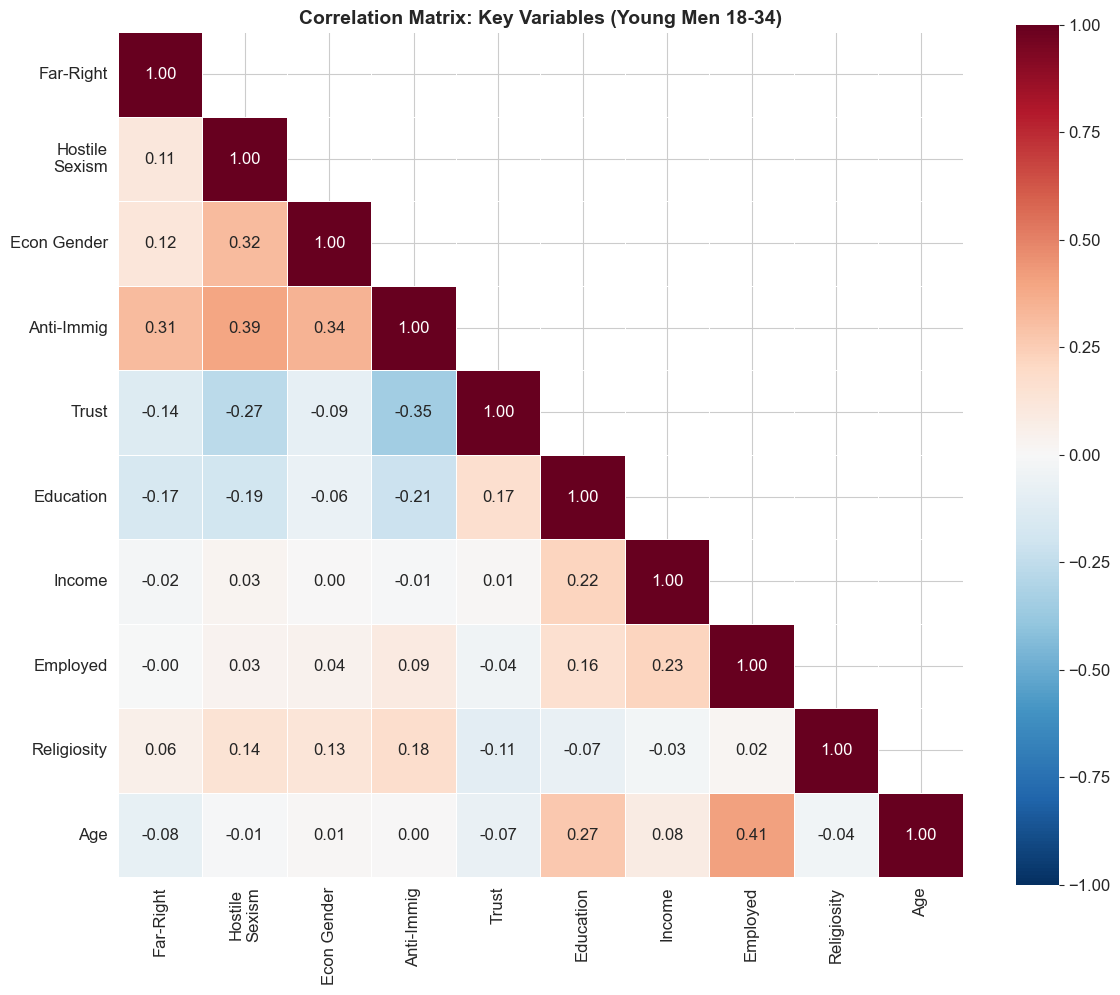

In [36]:


corr_vars = ['far_right', 'hostile_sexism', 'econ_gender', 'anti_immigration',
             'political_trust', 'education', 'income', 'employed', 'religiosity', 'age']

corr_matrix = df_analysis[corr_vars].corr()
print("\nCorrelation matrix:")
print(corr_matrix.round(3))

r_hs_eg = corr_matrix.loc['hostile_sexism', 'econ_gender']
print(f"\n*** Key correlation: hostile_sexism <-> econ_gender: r = {r_hs_eg:.3f} ***")

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            xticklabels=['Far-Right', 'Hostile\nSexism', 'Econ Gender', 'Anti-Immig',
                         'Trust', 'Education', 'Income', 'Employed', 'Religiosity', 'Age'],
            yticklabels=['Far-Right', 'Hostile\nSexism', 'Econ Gender', 'Anti-Immig',
                         'Trust', 'Education', 'Income', 'Employed', 'Religiosity', 'Age'])
ax.set_title('Correlation Matrix: Key Variables (Young Men 18-34)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix_2.png', dpi=300, bbox_inches='tight')
plt.show()

In [37]:
vif_vars = ['hostile_sexism', 'econ_gender', 'anti_immigration', 'political_trust',
            'education', 'income', 'employed', 'religiosity', 'age']
X_vif = sm.add_constant(df_analysis[vif_vars])
vif_data = pd.DataFrame({
    'Variable': vif_vars,
    'VIF': [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_vars))]
})
print(vif_data.to_string(index=False))

        Variable      VIF
  hostile_sexism 1.296477
     econ_gender 1.198744
anti_immigration 1.417583
 political_trust 1.199143
       education 1.225835
          income 1.103212
        employed 1.277882
     religiosity 1.047838
             age 1.292513


In [40]:
import pandas as pd
import statsmodels.formula.api as smf

df_analysis = df_analysis.copy()
df_analysis["far_right"] = df_analysis["far_right"].astype(int)
df_analysis["cntry"] = df_analysis["cntry"].astype("category")

print("\nFitting Model 1 (Baseline)...")
m1 = smf.logit(
    "far_right ~ anti_immigration + political_trust + education + income + employed + age + religiosity + urban + C(cntry)",
    data=df_analysis
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_analysis["cntry"]},
    disp=False
)

print("Fitting Model 2 (+ Hostile Sexism)...")
m2 = smf.logit(
    "far_right ~ hostile_sexism + anti_immigration + political_trust + education + income + employed + age + religiosity + urban + C(cntry)",
    data=df_analysis
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_analysis["cntry"]},
    disp=False
)

print("Fitting Model 3 (+ Economic Gender Attitudes)...")
m3 = smf.logit(
    "far_right ~ econ_gender + anti_immigration + political_trust + education + income + employed + age + religiosity + urban + C(cntry)",
    data=df_analysis
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_analysis["cntry"]},
    disp=False
)

print("Fitting Model 4 (+ Both)...")
m4 = smf.logit(
    "far_right ~ hostile_sexism + econ_gender + anti_immigration + political_trust + education + income + employed + age + religiosity + urban + C(cntry)",
    data=df_analysis
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_analysis["cntry"]},
    disp=False
)

print(m1.summary())
print(m2.summary())
print(m3.summary())
print(m4.summary())


Fitting Model 1 (Baseline)...
Fitting Model 2 (+ Hostile Sexism)...
Fitting Model 3 (+ Economic Gender Attitudes)...
Fitting Model 4 (+ Both)...
                           Logit Regression Results                           
Dep. Variable:              far_right   No. Observations:                 1486
Model:                          Logit   Df Residuals:                     1455
Method:                           MLE   Df Model:                           30
Date:                Mon, 09 Mar 2026   Pseudo R-squ.:                  0.2536
Time:                        21:43:33   Log-Likelihood:                -487.93
converged:                       True   LL-Null:                       -653.75
Covariance Type:              cluster   LLR p-value:                 1.440e-52
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.3196      0.864      0.370   